In [7]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [8]:
# ============================================================================
# STEP 1: DEFINE MFCC EXTRACTION FUNCTION
# ============================================================================

def extract_mfcc_features(file_path, n_mfcc=13, n_fft=2048, hop_length=512, max_len=100):
    """
    Extract MFCC features from an audio file.
    
    Args:
        file_path: Path to the audio file
        n_mfcc: Number of MFCC coefficients (default: 13)
        n_fft: FFT window size (default: 2048)
        hop_length: Number of samples between successive frames (default: 512)
        max_len: Maximum number of frames to keep (default: 100)
    
    Returns:
        np.ndarray of shape (max_len, n_mfcc) or None if extraction fails
    """
    try:
        # Load the audio file
        audio_signal, sr = librosa.load(file_path, sr=None)
        
        # Extract MFCC features
        # Returns shape (n_mfcc, time_steps)
        mfcc = librosa.feature.mfcc(
            y=audio_signal, 
            sr=sr, 
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            hop_length=hop_length
        )
        
        # Transpose to (time_steps, n_mfcc)
        mfcc = mfcc.T
        
        # Pad or truncate to fixed length
        if mfcc.shape[0] < max_len:
            # Pad with zeros if too short
            padding = np.zeros((max_len - mfcc.shape[0], n_mfcc))
            mfcc = np.vstack([mfcc, padding])
        else:
            # Truncate if too long
            mfcc = mfcc[:max_len, :]
        
        return mfcc
    
    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return None

print('✅ MFCC extraction function defined!')

✅ MFCC extraction function defined!


In [9]:
# ============================================================================
# STEP 2: SET DATA PATH AND VERIFY FILES EXIST
# ============================================================================

DATA_PATH = '/kaggle/input/datasets/tejasbhalekar1/emotion-dataset/'

print(f"Looking for audio files in: {DATA_PATH}\n")

# Find all .wav files
wav_files = []
for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.wav'):
            wav_files.append(os.path.join(root, file))

print(f"Found {len(wav_files)} audio files\n")

if len(wav_files) > 0:
    print("Sample files:")
    for f in wav_files[:5]:
        print(f"  - {os.path.basename(f)}")
else:
    print("⚠️  No .wav files found! Check your DATA_PATH.")

Looking for audio files in: /kaggle/input/datasets/tejasbhalekar1/emotion-dataset/

Found 2880 audio files

Sample files:
  - 03-01-08-01-01-01-02.wav
  - 03-01-01-01-01-01-02.wav
  - 03-01-07-02-01-02-02.wav
  - 03-01-07-01-01-02-02.wav
  - 03-01-01-01-02-01-02.wav


In [10]:
# ============================================================================
# STEP 3: EXTRACT FEATURES FROM ALL AUDIO FILES
# ============================================================================

X = []  # Features
y = []  # Labels (emotion codes)
failed_count = 0

print(f"Extracting MFCC features from {len(wav_files)} files...\n")

for idx, file_path in enumerate(wav_files):
    # Show progress
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(wav_files)} files...")
    
    try:
        filename = os.path.basename(file_path)
        
        # Extract emotion label from filename
        # RAVDESS format: 03-01-05-01-01-01-01.wav
        # Position [2] = emotion code (01-08)
        parts = filename.split('-')
        emotion = int(parts[2])
        
        # Extract MFCC features
        mfcc = extract_mfcc_features(file_path, n_mfcc=13, max_len=100)
        
        if mfcc is not None:
            X.append(mfcc)
            y.append(emotion)
        else:
            failed_count += 1
    
    except Exception as e:
        print(f"  ⚠️  Skipping {filename}: {e}")
        failed_count += 1
        continue

# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)

print(f"\n✅ Feature extraction complete!")
print(f"  Successfully processed: {len(X)} files")
print(f"  Failed: {failed_count} files")
print(f"\n📊 Data shape: {X.shape}")
print(f"   X: (samples={X.shape[0]}, timesteps={X.shape[1]}, features={X.shape[2]})")
print(f"   y: {y.shape}")
print(f"\n🏷️  Emotion classes: {np.unique(y)}")

Extracting MFCC features from 2880 files...

  Processed 50/2880 files...
  Processed 100/2880 files...
  Processed 150/2880 files...
  Processed 200/2880 files...
  Processed 250/2880 files...
  Processed 300/2880 files...
  Processed 350/2880 files...
  Processed 400/2880 files...
  Processed 450/2880 files...
  Processed 500/2880 files...
  Processed 550/2880 files...
  Processed 600/2880 files...
  Processed 650/2880 files...
  Processed 700/2880 files...
  Processed 750/2880 files...
  Processed 800/2880 files...
  Processed 850/2880 files...
  Processed 900/2880 files...
  Processed 950/2880 files...
  Processed 1000/2880 files...
  Processed 1050/2880 files...
  Processed 1100/2880 files...
  Processed 1150/2880 files...
  Processed 1200/2880 files...
  Processed 1250/2880 files...
  Processed 1300/2880 files...
  Processed 1350/2880 files...
  Processed 1400/2880 files...
  Processed 1450/2880 files...
  Processed 1500/2880 files...
  Processed 1550/2880 files...
  Processed 16

In [11]:
# ============================================================================
# STEP 4: PREPARE DATA FOR MODEL
# ============================================================================

if len(X) > 10:  # Ensure we have enough data
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Encode emotion labels to start from 0
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_test = label_encoder.transform(y_test)
    
    print("✅ Data split and encoded!")
    print(f"\n📈 Training set: {X_train.shape[0]} samples")
    print(f"📈 Test set: {X_test.shape[0]} samples")
    print(f"\n🏷️  Emotion mapping:")
    for i, emotion_code in enumerate(label_encoder.classes_):
        print(f"   Class {i} -> Emotion {emotion_code}")
    
    num_classes = len(label_encoder.classes_)
    print(f"\nTotal classes: {num_classes}")
else:
    print(f"❌ Not enough data! Need at least 10 samples, but got {len(X)}")

✅ Data split and encoded!

📈 Training set: 2304 samples
📈 Test set: 576 samples

🏷️  Emotion mapping:
   Class 0 -> Emotion 1
   Class 1 -> Emotion 2
   Class 2 -> Emotion 3
   Class 3 -> Emotion 4
   Class 4 -> Emotion 5
   Class 5 -> Emotion 6
   Class 6 -> Emotion 7
   Class 7 -> Emotion 8

Total classes: 8


In [12]:
# ============================================================================
# STEP 5: BUILD CNN MODEL
# ============================================================================

model = Sequential([
    # First Conv Block
    Conv1D(
        filters=32, 
        kernel_size=5, 
        activation='relu', 
        input_shape=(X_train.shape[1], X_train.shape[2]),
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Second Conv Block
    Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Third Conv Block
    Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🧠 Model Architecture:")
print("=" * 70)
model.summary()

🧠 Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 100, 32)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 25, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481,800 (1.84 MB)

 Trainable params: 481,352 (1.84 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# ============================================================================
# STEP 6: TRAIN MODEL
# ============================================================================

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.1789 - loss: 3.0280 - val_accuracy: 0.1302 - val_loss: 2.4659
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1840 - loss: 2.1780 - val_accuracy: 0.1974 - val_loss: 2.0009
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2153 - loss: 2.0179 - val_accuracy: 0.2711 - val_loss: 1.9217
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2546 - loss: 1.9313 - val_accuracy: 0.2538 - val_loss: 1.8950
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2158 - loss: 1.9271 - val_accuracy: 0.2733 - val_loss: 1.8561
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2341 - loss: 1.9245 - val_accuracy: 0.2603 - val_loss: 1.8734
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2756 - loss: 1.8565 - val_accuracy: 0.2972 - val_loss: 1.8555
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2695 - loss: 1.8603 - val_accuracy: 0.

In [14]:
# ============================================================================
# STEP 7: EVALUATE MODEL
# ============================================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE")
print("="*70)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*70)


📊 MODEL PERFORMANCE
Test Loss:     1.5579
Test Accuracy: 0.3941 (39.41%)


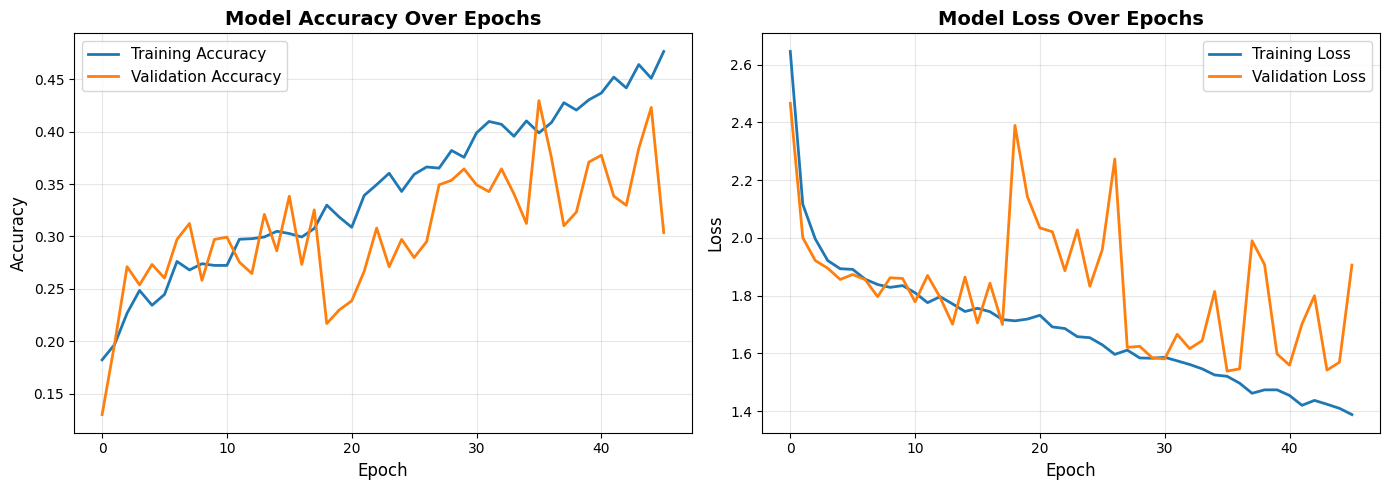

✅ Plots generated!


In [15]:
# ============================================================================
# STEP 8: PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Plots generated!")

In [16]:
# ============================================================================
# STEP 9: DETAILED EVALUATION (OPTIONAL)
# ============================================================================

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\n📋 Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_classes, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("\n🔍 Confusion Matrix:")
print(cm)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           0     0.2500    0.0263    0.0476        38
           1     0.4400    0.8684    0.5841        76
           2     0.2326    0.2597    0.2454        77
           3     0.3659    0.1948    0.2542        77
           4     0.6301    0.5974    0.6133        77
           5     0.3816    0.3766    0.3791        77
           6     0.3250    0.5065    0.3959        77
           7     0.4231    0.1429    0.2136        77

    accuracy                         0.3941       576
   macro avg     0.3810    0.3716    0.3417       576
weighted avg     0.3898    0.3941    0.3611       576


🔍 Confusion Matrix:
[[ 1 27  1  1  0  1  6  1]
 [ 0 66  3  3  0  1  2  1]
 [ 3 10 20  2  5 14 19  4]
 [ 0 23 13 15  1  7 17  1]
 [ 0  1 11  0 46 12  6  1]
 [ 0  5 17  6 10 29  9  1]
 [ 0  8  4 10  3  7 39  6]
 [ 0 10 17  4  8  5 22 11]]
